# Preprocessing

This notebook converts the canonical processed DENTEX dataset into forms required by object-detection frameworks while preserving image information, bounding-box geometry, class labels, split membership, and reproducibility. It examines resize behavior, normalization contracts, conservative augmentation candidates, synchronized box transformations, and model-specific annotation conversion.

The canonical COCO-compatible dataset remains the source of truth. Demonstrated transformations do not imply that a second permanently resized or normalized image dataset is created. Resize, tensor conversion, normalization, and stochastic training augmentation may be applied dynamically by the selected framework at training or inference time. The notebook materializes only the required YOLO-compatible representation under `data/model_ready/dentex_yolo/`.

## 1. Canonical Input Representation

The preprocessing input is the fixed dataset produced by `00_prepare_dataset.ipynb`: `train.json`, `val.json`, and `test.json` plus their corresponding image directories. Each COCO-compatible annotation uses

$$
\mathbf{b}=[x,y,w,h],
$$

where $x$ and $y$ locate the upper-left corner and $w$ and $h$ are width and height in pixels. Every object remains linked to one image and one of the four diagnosis classes.

The radiographs contain grayscale visual information, but the actual canonical PNG files are encoded as three-channel `RGB uint8`, as verified below. Pixel intensities therefore remain in the integer domain

$$
I(x,y,k)\in\{0,\ldots,255\},
$$

for stored channel $k$. Analysis and visual demonstrations may convert the RGB encoding to a single luminance channel at runtime; this does not rewrite the canonical files. Normalization is likewise not baked into those files.

The data relationship is one-directional:

```text
Canonical COCO representation
            ↓
runtime preprocessing or model-specific conversion
            ↓
framework-ready representation
```

DataFrames and dictionaries constructed here are runtime analysis objects, not competing sources of truth.

In [1]:
from collections import defaultdict
import hashlib, json, math, random, shutil
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance, ImageFilter, ImageOps

SEED=42
SPLITS=("train","val","test")
CLASS_NAMES={0:"Impacted",1:"Caries",2:"Periapical Lesion",3:"Deep Caries"}
CLASS_COLORS={0:"#e76f51",1:"#2a9d8f",2:"#e9c46a",3:"#457b9d"}
TARGET_SIZES=(640,1024)
LETTERBOX_COLOR=114
AUGMENTATION_CONFIG={"degrees":5.0,"translate":0.03,"scale":0.08,"horizontal_flip_probability":0.0,
                     "brightness":0.10,"contrast":0.10,"gamma_range":(0.90,1.10),"noise_std":3.0,"blur_radius":0.5}
random.seed(SEED); np.random.seed(SEED)
plt.rcParams.update({"figure.dpi":110,"axes.grid":False})

cwd=Path.cwd().resolve()
PROJECT_ROOT=cwd if (cwd/"data"/"processed"/"dentex_diagnosis").is_dir() else cwd.parent
DATA_ROOT=PROJECT_ROOT/"data"/"processed"/"dentex_diagnosis"
MODEL_ROOT=PROJECT_ROOT/"data"/"model_ready"/"dentex_yolo"
display(pd.DataFrame({"Value":[DATA_ROOT,MODEL_ROOT,SEED,AUGMENTATION_CONFIG["horizontal_flip_probability"]]},index=["Canonical COCO input","Derived YOLO output","Random seed","Default horizontal-flip probability"]))

,Value
Canonical COCO input,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
Derived YOLO output,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
Random seed,42
Default horizontal-flip probability,0.0


In [2]:
def load_detection_dataset(root):
    payloads={}; image_rows=[]; box_rows=[]
    for split in SPLITS:
        with (root/"annotations"/f"{split}.json").open(encoding="utf-8") as f: payload=json.load(f)
        categories={int(x["id"]):x["name"] for x in payload["categories"]}
        if categories!=CLASS_NAMES: raise ValueError(f"Unexpected classes in {split}: {categories}")
        lookup={int(x["id"]):x for x in payload["images"]}; payloads[split]=payload
        for im in payload["images"]:
            path=root/"images"/split/im["file_name"]
            if not path.is_file(): raise FileNotFoundError(path)
            image_rows.append({"split":split,"image_id":int(im["id"]),"file_name":im["file_name"],"width":int(im["width"]),"height":int(im["height"]),"path":path})
        for a in payload["annotations"]:
            im=lookup.get(int(a["image_id"])); x,y,w,h=map(float,a["bbox"])
            if im is None or w<=0 or h<=0 or x<0 or y<0 or x+w>im["width"]+1e-6 or y+h>im["height"]+1e-6: raise ValueError(f"Invalid annotation {a['id']}")
            box_rows.append({"split":split,"annotation_id":int(a["id"]),"image_id":int(a["image_id"]),"class_id":int(a["category_id"]),"x":x,"y":y,"w":w,"h":h,
                             "relative_area":w*h/(im["width"]*im["height"])})
    return payloads,pd.DataFrame(image_rows),pd.DataFrame(box_rows)

In [3]:
payloads,images_df,boxes_df=load_detection_dataset(DATA_ROOT)
input_summary=pd.DataFrame({"Images":[len(images_df)],"Annotations":[len(boxes_df)],"Splits":[", ".join(SPLITS)],"Classes":[len(CLASS_NAMES)]})
display(input_summary)

,Images,Annotations,Splits,Classes
0,705,3529,"train, val, test",4


The loaded records retain all 705 canonical images and 3,529 annotations. No annotation coordinates, class IDs, filenames, or split assignments are changed.

### Representative Canonical Examples

Before transforming any image, representative training examples are chosen from measured dataset properties: a typical-density image, a dense image, the image containing the smallest relative-area box, and an image containing the rarest class. Overlaying canonical boxes establishes a visual reference for subsequent transformation checks.

In [4]:
def select_representative_examples(images,boxes):
    counts=boxes.groupby("image_id").size(); data=images.copy(); data["n"]=data.image_id.map(counts).fillna(0)
    train=data[data.split=="train"]
    typical=train.iloc[(train.n-train.n.median()).abs().argsort()].iloc[0]
    dense=train.sort_values(["n","image_id"],ascending=[False,True]).iloc[0]
    smallest=boxes[(boxes.split=="train")].sort_values("relative_area").iloc[0]
    rare_id=int(boxes.class_id.value_counts().idxmin()); rare_image=boxes[(boxes.split=="train")&(boxes.class_id==rare_id)].image_id.min()
    ids=[int(typical.image_id),int(dense.image_id),int(smallest.image_id),int(rare_image)]
    names=["Typical","Multiple objects","Small-object","Rarest class"]
    return {name:images[images.image_id==iid].iloc[0] for name,iid in zip(names,ids)}, int(smallest.annotation_id)

def get_image_boxes(row):
    image=np.array(Image.open(row.path).convert("L")); b=boxes_df[boxes_df.image_id==row.image_id][["x","y","w","h","class_id","annotation_id"]].to_numpy(float)
    return image,b

def draw_detection(ax,image,boxes,title,show_dims=False):
    ax.imshow(image,cmap="gray",vmin=0,vmax=255)
    for x,y,w,h,c,*_ in boxes:
        ax.add_patch(Rectangle((x,y),w,h,fill=False,lw=1.5,color=CLASS_COLORS[int(c)]))
        label=CLASS_NAMES[int(c)]+(f" {w:.0f}×{h:.0f}" if show_dims else "")
        ax.text(x,max(0,y-4),label,color="white",fontsize=6,bbox={"facecolor":CLASS_COLORS[int(c)],"alpha":.8,"pad":1})
    ax.set_title(f"{title}\n{image.shape[1]}×{image.shape[0]}"); ax.axis("off")

def visualize_original_examples(examples):
    fig,axes=plt.subplots(2,2,figsize=(16,8))
    for ax,(name,row) in zip(axes.flat,examples.items()):
        image,boxes=get_image_boxes(row); draw_detection(ax,image,boxes,name,True)
    fig.legend([Patch(color=CLASS_COLORS[i],label=CLASS_NAMES[i]) for i in CLASS_NAMES],CLASS_NAMES.values(),loc="upper center",ncol=4)
    plt.tight_layout(); plt.show()

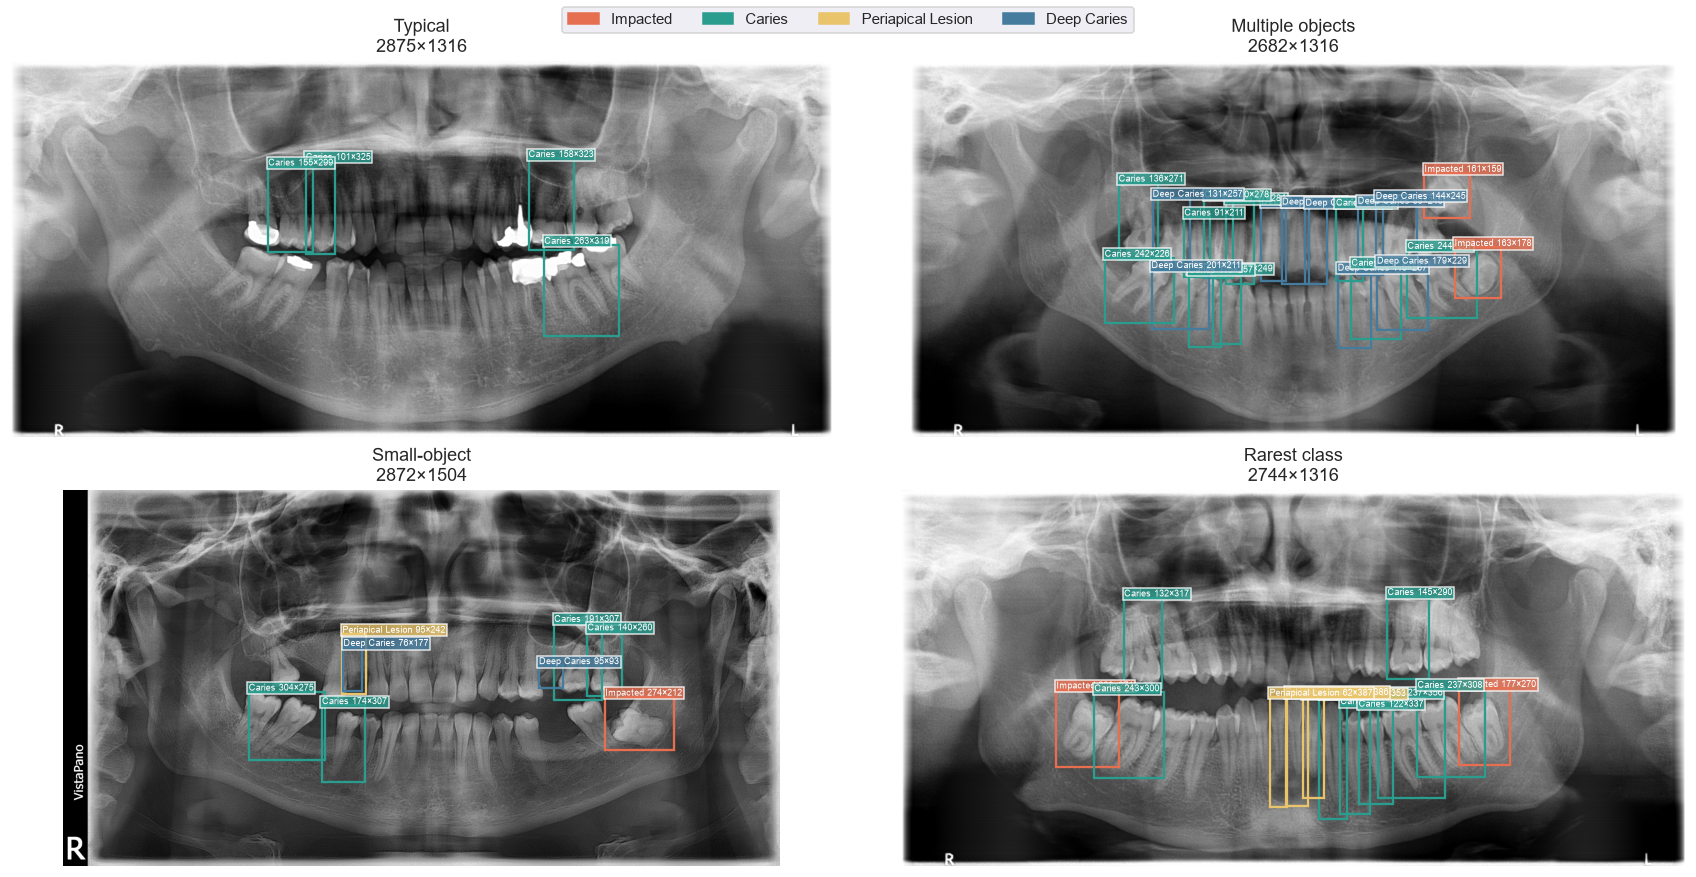

In [5]:
examples,smallest_annotation_id=select_representative_examples(images_df,boxes_df)
visualize_original_examples(examples)

**Observation.** The canonical examples expose typical, dense, rare-class, and small-object cases before preprocessing. Reusing them below makes coordinate drift and geometric distortion easier to detect.

## 2. Resize Strategy

DENTEX panoramas have variable resolution and aspect ratio, while detectors require model-compatible input dimensions. A resize operation must therefore transform both pixels and bounding boxes.

For direct resize from source $(W,H)$ to $(W_t,H_t)$, the independent scale factors are

$$
s_x=\frac{W_t}{W},\qquad s_y=\frac{H_t}{H}.
$$

When $s_x\neq s_y$, horizontal and vertical dimensions are scaled differently. This operation is mathematically valid, but square stretching changes the proportions of the panorama, anatomical structures, and annotated objects, so it is rejected as the preferred strategy.

Letterbox resize instead uses the isotropic factor

$$
s=\min\left(\frac{W_t}{W},\frac{H_t}{H}\right),
$$

with resized dimensions

$$
W'=sW,\qquad H'=sH.
$$

The unused canvas area is filled with padding. Each bounding box is scaled by the same $s$ and shifted by the horizontal and vertical padding offsets, preserving image and object proportions.

In [6]:
def direct_resize(image,boxes,target):
    h,w=image.shape; sx,sy=target/w,target/h
    out=np.array(Image.fromarray(image).resize((target,target),Image.Resampling.BILINEAR)); b=boxes.copy(); b[:,[0,2]]*=sx; b[:,[1,3]]*=sy
    return out,b,{"scale_x":sx,"scale_y":sy,"pad_x":0,"pad_y":0}

def letterbox_image_and_boxes(image,boxes,target,color=114):
    h,w=image.shape; scale=min(target/w,target/h); nw,nh=round(w*scale),round(h*scale); px=(target-nw)//2; py=(target-nh)//2
    resized=Image.fromarray(image).resize((nw,nh),Image.Resampling.BILINEAR); canvas=Image.new("L",(target,target),color); canvas.paste(resized,(px,py))
    b=boxes.copy(); b[:,:4]*=scale; b[:,0]+=px; b[:,1]+=py
    return np.array(canvas),b,{"scale_x":scale,"scale_y":scale,"pad_x":px,"pad_y":py}

def compare_resize_strategies(row,target=640):
    image,boxes=get_image_boxes(row); stretched,sb,sm=direct_resize(image,boxes,target); letterboxed,lb,lm=letterbox_image_and_boxes(image,boxes,target)
    fig,axes=plt.subplots(1,3,figsize=(17,6)); draw_detection(axes[0],image,boxes,"BEFORE — Original"); draw_detection(axes[1],stretched,sb,f"AFTER — Direct resize {target}"); draw_detection(axes[2],letterboxed,lb,f"AFTER — Letterbox {target}")
    plt.tight_layout(); plt.show()
    i=int(np.argmin(boxes[:,2]*boxes[:,3])); x,y,w,h,*_=boxes[i];
    return pd.DataFrame([{"strategy":"original","aspect_ratio":image.shape[1]/image.shape[0],"scale_x":1,"scale_y":1,"pad_x":0,"pad_y":0,"bbox_w":w,"bbox_h":h},
                         {"strategy":"direct resize","aspect_ratio":1,"bbox_w":sb[i,2],"bbox_h":sb[i,3],**sm},
                         {"strategy":"letterbox","aspect_ratio":image.shape[1]/image.shape[0],"bbox_w":lb[i,2],"bbox_h":lb[i,3],**lm}])

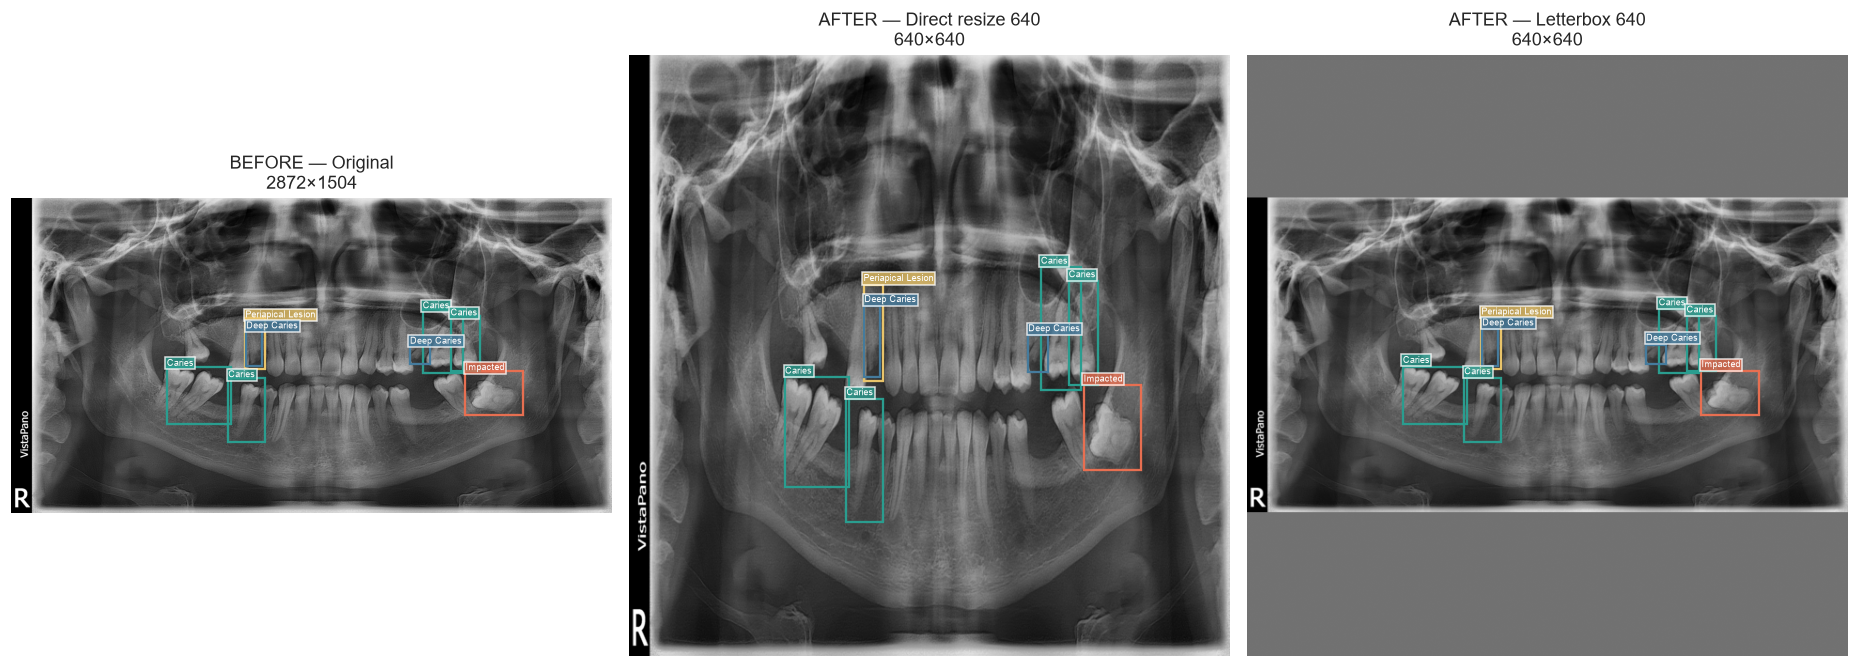

,strategy,aspect_ratio,scale_x,scale_y,pad_x,pad_y,bbox_w,bbox_h
0,original,1.91,1.000,1.000,0,0,94.595,93.243
1,direct resize,1.00,0.223,0.426,0,0,21.080,39.678
2,letterbox,1.91,0.223,0.223,0,152,21.080,20.778


In [7]:
resize_comparison=compare_resize_strategies(examples["Small-object"],640)
display(resize_comparison.round(3))

**Observation and decision.** In the displayed case, direct resize uses unequal horizontal and vertical scales and changes the box aspect geometry. Letterbox uses one common scale and adds vertical padding while the transformed boxes remain aligned. Aspect-ratio-preserving letterbox is therefore the baseline resize strategy; direct square stretching remains only a comparison.

## 3. Candidate Input Resolution

Input size controls the number of pixels available to represent an object as well as memory and computation. The existing comparison projects the same small annotation onto $640\times640$ and $1024\times1024$ letterbox canvases. Linear dimensions increase by

$$
\frac{1024}{640}=1.6.
$$

Thus, 640 is computationally cheaper, whereas 1024 preserves more pixels per object. These values are illustrative preprocessing candidates rather than a final hyperparameter choice.

In [8]:
def compare_input_resolutions(row,annotation_id):
    image,boxes=get_image_boxes(row); idx=np.where(boxes[:,-1]==annotation_id)[0][0]; panels=[]; records=[]
    for target in TARGET_SIZES:
        transformed,tboxes,meta=letterbox_image_and_boxes(image,boxes,target); panels.append((target,transformed,tboxes))
        records.append({"resolution":target,"bbox_width_px":tboxes[idx,2],"bbox_height_px":tboxes[idx,3],"short_side_px":min(tboxes[idx,2:4]),"scale":meta["scale_x"]})
    fig,axes=plt.subplots(2,2,figsize=(13,11))
    for col,(target,img,bxs) in enumerate(panels):
        draw_detection(axes[0,col],img,bxs,f"Letterbox {target}")
        x,y,w,h,*_=bxs[idx]; margin=max(w,h)*1.5; axes[1,col].imshow(img,cmap="gray",vmin=0,vmax=255); axes[1,col].set_xlim(max(0,x-margin),min(target,x+w+margin)); axes[1,col].set_ylim(min(target,y+h+margin),max(0,y-margin)); axes[1,col].add_patch(Rectangle((x,y),w,h,fill=False,lw=2,color="red")); axes[1,col].set_title(f"Zoom — {w:.1f}×{h:.1f} px"); axes[1,col].axis("off")
    plt.tight_layout(); plt.show(); return pd.DataFrame(records)

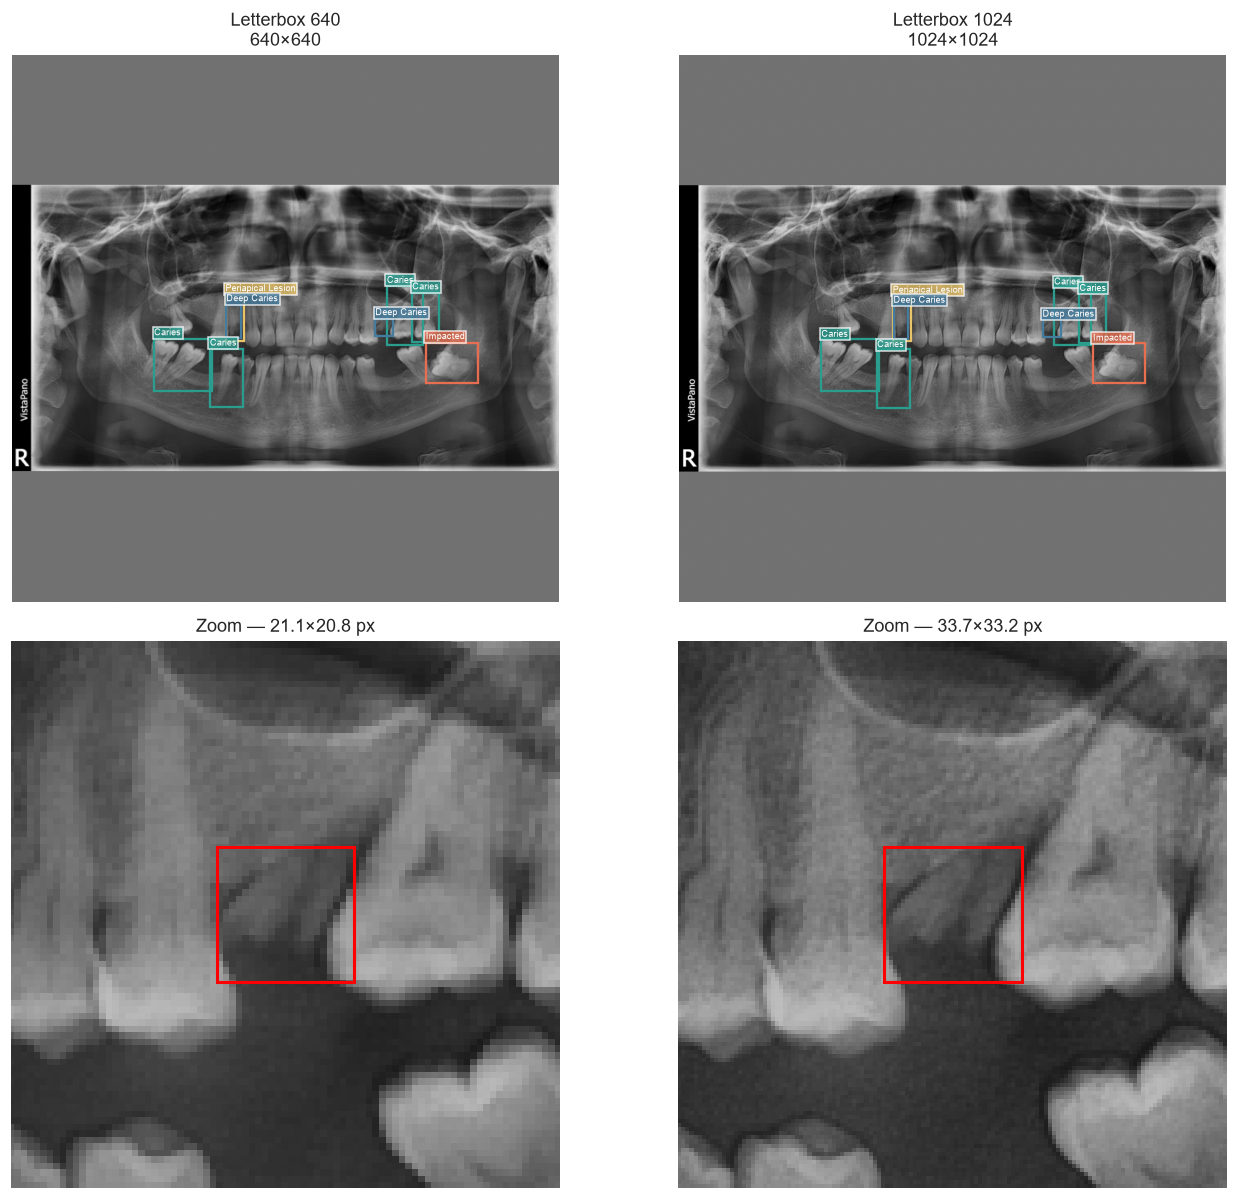

,resolution,bbox_width_px,bbox_height_px,short_side_px,scale
0,640,21.08,20.78,20.78,0.22
1,1024,33.73,33.25,33.25,0.36


In [9]:
resolution_comparison=compare_input_resolutions(examples["Small-object"],smallest_annotation_id)
display(resolution_comparison.round(2))

**Observation and implication.** The selected small box grows from approximately $21.1\times20.8$ pixels at 640 to $33.7\times33.3$ pixels at 1024, consistent with the 1.6 linear ratio. Higher resolution may help localize small regions but increases memory use and computation. The final input resolution is an empirical modeling parameter determined later during controlled refinement, not a decision made solely by EDA or preprocessing.

## 4. Normalization

Canonical images remain `uint8`; the notebook does not save a separately normalized copy. For a framework contract that scales intensities by 255, such as the relevant Ultralytics runtime path, the effective transformation is

$$
I_{\mathrm{norm}}=\frac{I}{255},\qquad I_{\mathrm{norm}}\in[0,1].
$$

Additional standardization,

$$
I'=\frac{I_{\mathrm{norm}}-\mu}{\sigma},
$$

must not be applied unless required by the selected model and framework. Different frameworks can define different preprocessing contracts. Manually repeating normalization already performed internally creates a risk of double preprocessing and inconsistent intensity distributions.

The operational requirement is that training and inference use the same effective preprocessing contract. The canonical dataset remains framework-neutral, and dynamic normalization follows the selected runtime.

In [10]:
def analyze_pixel_distribution(rows):
    records=[]; arrays=[]
    for _,row in rows.iterrows():
        im=Image.open(row.path); arr=np.array(im); arrays.append(arr.ravel()); records.append({"file_name":row.file_name,"mode":im.mode,"dtype":str(arr.dtype),"channels":1 if arr.ndim==2 else arr.shape[2],"min":int(arr.min()),"max":int(arr.max()),"mean":float(arr.mean()),"std":float(arr.std())})
    fig,axes=plt.subplots(1,2,figsize=(13,4)); axes[0].imshow(np.array(Image.open(rows.iloc[0].path)),cmap="gray",vmin=0,vmax=255); axes[0].set_title("Original uint8 panorama"); axes[0].axis("off")
    for arr,label in zip(arrays,rows.file_name): axes[1].hist(arr,bins=128,range=(0,255),density=True,histtype="step",label=label)
    axes[1].set(title="Representative intensity distributions",xlabel="Pixel value",ylabel="Density"); axes[1].legend(fontsize=7); plt.tight_layout(); plt.show(); return pd.DataFrame(records)

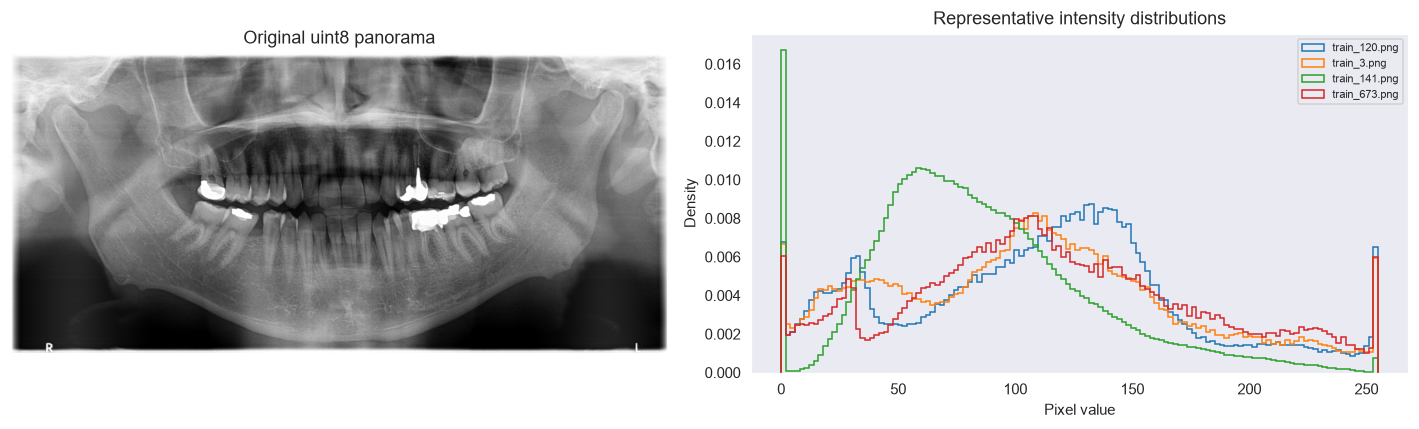

,file_name,mode,dtype,channels,min,max,mean,std
0,train_120.png,RGB,uint8,3,0,255,111.21,59.56
1,train_3.png,RGB,uint8,3,0,255,108.05,61.09
2,train_141.png,RGB,uint8,3,0,255,85.81,45.38
3,train_673.png,RGB,uint8,3,0,255,116.45,61.13


In [11]:
pixel_report=analyze_pixel_distribution(pd.DataFrame(examples.values()))
display(pixel_report.round(2))

**Observation.** The inspected files are `RGB uint8` with three stored channels and values spanning `[0,255]`. The radiographic images are converted to luminance for notebook visualization, but the source PNG encoding remains unchanged. No additional normalized image dataset is required.

## 5. Data Augmentation Policy

Augmentation is a stochastic training-time strategy, not a permanent modification of the canonical dataset. Medical imagery requires conservative transformations because excessive geometric or intensity changes can create anatomically implausible examples or damage diagnostically relevant signal.

### Geometric candidates

The demonstrated conservative ranges are rotation within approximately $\pm5^\circ$, translation up to approximately 3% of image dimensions, and scale in the range 0.92–1.08. Horizontal flipping is disabled by default (`horizontal_flip_probability = 0.0`) and appears below only as an explicitly labelled candidate for visual inspection. Vertical flips, large rotations, aggressive perspective, aggressive shear, and aggressive random crops are excluded from the baseline policy. Cropping is particularly risky because it may partially or fully remove peripheral targets.

Geometric operations must transform images and bounding boxes jointly.

### Photometric candidates

Moderate brightness, contrast, gamma, weak noise, and weak blur alter pixel appearance without changing bounding-box geometry. Demonstrating them does not establish that they improve the final model. Excessive intensity manipulation may erase local radiographic evidence rather than improve generalization.

The intended policy separation is:

```text
Training:        canonical image → runtime resize → stochastic augmentation → normalization → model input
Validation/Test: canonical image → deterministic runtime resize → normalization → model input
```

Validation and test receive no stochastic augmentation.

## 6. Bounding-Box Transformations

Image geometry and annotation geometry must remain synchronized. Resize scales coordinates; letterbox additionally applies padding offsets; affine transformations map all box corners and reconstruct an axis-aligned enclosing box. Where a transformed box crosses the image boundary, clipping may constrain it to the valid canvas, after which its dimensions must be checked again.

For corner coordinates on a transformed canvas $(W,H)$, validity requires

$$
0\leq x_1<x_2\leq W,
\qquad
0\leq y_1<y_2\leq H,
$$

equivalently $w>0$ and $h>0$ in $[x,y,w,h]$ form. The class label and annotation identity must remain associated with the transformed box. If a transformation removes an object or produces a degenerate box, that change must be explicit and reported. The governing principle is **no silent annotation corruption**.

## 7. Visual Validation of Geometric Transformations

The following panels apply the implemented affine transformations to an actual project image and its boxes. Their purpose is functional validation: correct coordinate scaling, correct padding or affine mapping, in-bound clipping, preserved labels, and absence of visible annotation drift.

In [12]:
def affine_image_and_boxes(image,boxes,angle=0,dx=0,dy=0,scale=1,flip=False):
    h,w=image.shape; cx,cy=w/2,h/2; rad=math.radians(angle); c,s=math.cos(rad)*scale,math.sin(rad)*scale
    F=np.array([[c,-s,cx+dx-c*cx+s*cy],[s,c,cy+dy-s*cx-c*cy],[0,0,1]],float)
    if flip: F=np.array([[-1,0,w],[0,1,0],[0,0,1]],float)@F
    inv=np.linalg.inv(F); out=np.array(Image.fromarray(image).transform((w,h),Image.Transform.AFFINE,tuple(inv[:2].ravel()),Image.Resampling.BILINEAR,fillcolor=0))
    transformed=[]
    for x,y,bw,bh,cls,aid in boxes:
        pts=np.array([[x,y,1],[x+bw,y,1],[x+bw,y+bh,1],[x,y+bh,1]])@F.T; xs=np.clip(pts[:,0],0,w); ys=np.clip(pts[:,1],0,h)
        nx,ny,nw,nh=xs.min(),ys.min(),xs.max()-xs.min(),ys.max()-ys.min()
        if nw>=1 and nh>=1: transformed.append([nx,ny,nw,nh,cls,aid])
    return out,np.asarray(transformed,float),F

def visualize_geometric_augmentations(row):
    image,boxes=get_image_boxes(row); specs=[("BEFORE — Original",{}),("AFTER — Rotation +5°",{"angle":5}),("AFTER — Translation 3%",{"dx":.03*image.shape[1],"dy":.03*image.shape[0]}),("AFTER — Scale 1.08×",{"scale":1.08}),("AFTER — Horizontal flip (candidate only)",{"flip":True})]
    results=[]; fig,axes=plt.subplots(2,3,figsize=(17,9));
    for ax,(title,kwargs) in zip(axes.flat,specs):
        out,b,_=affine_image_and_boxes(image,boxes,**kwargs); draw_detection(ax,out,b,title); results.append((title,out,b))
    axes.flat[-1].axis("off"); plt.tight_layout(); plt.show(); return results

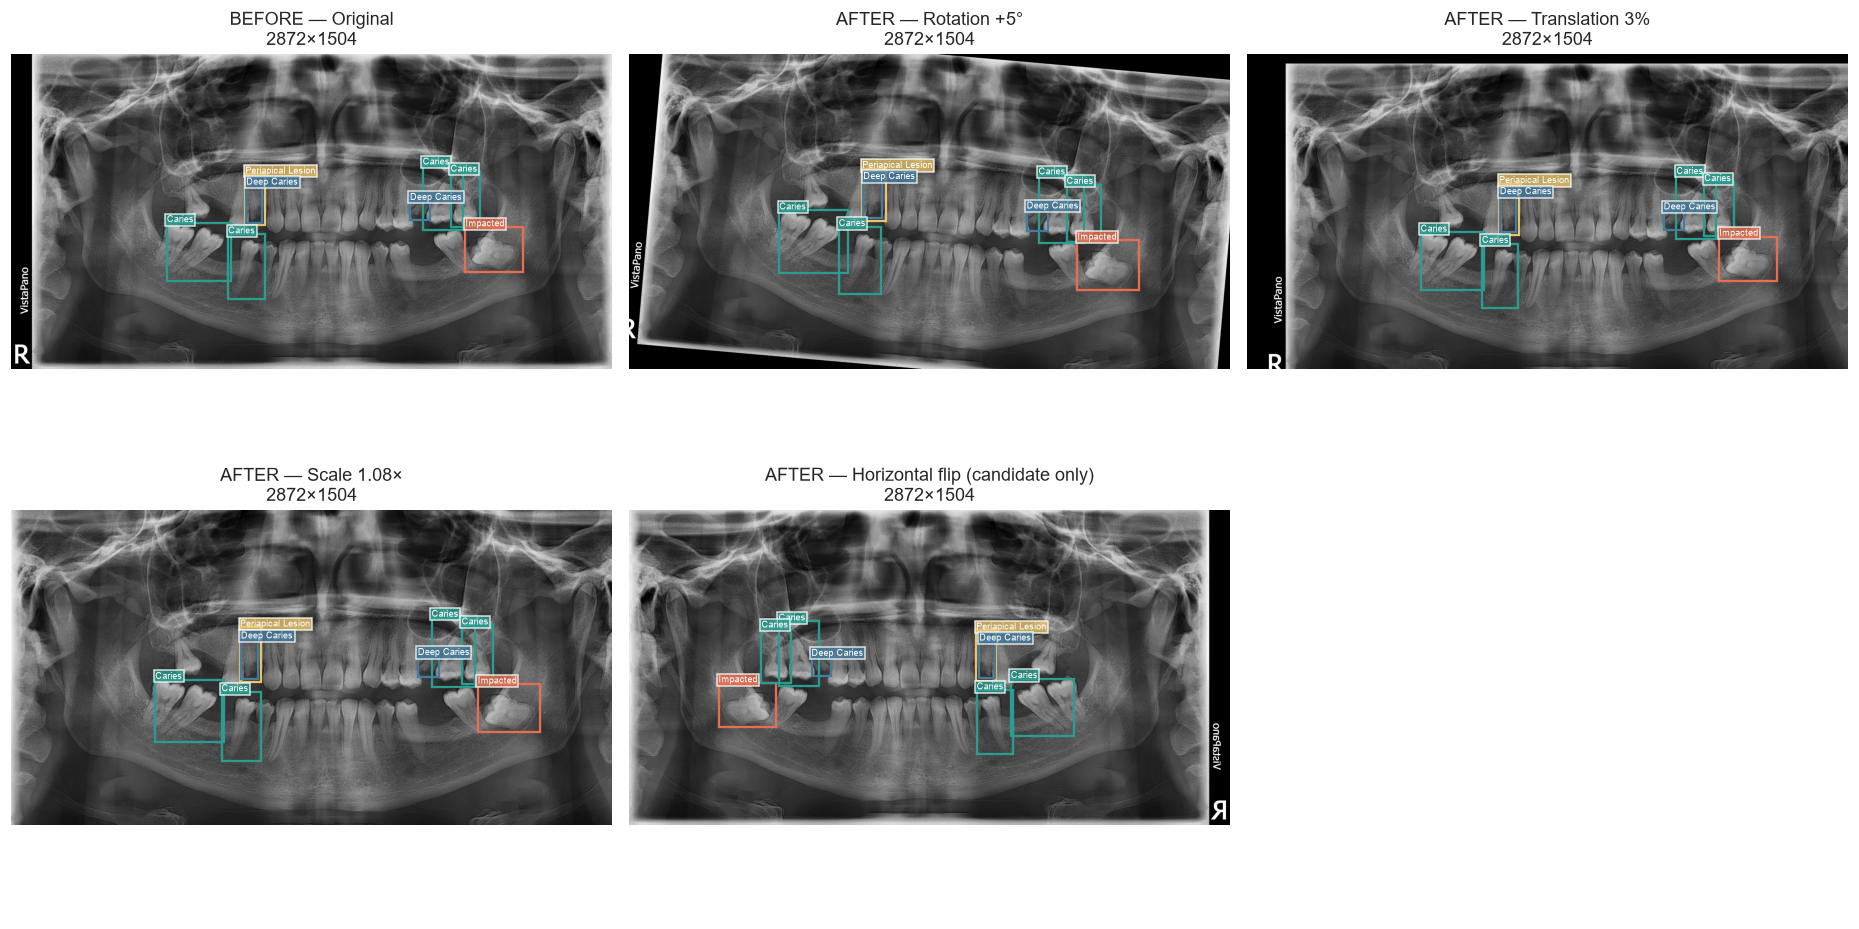

In [13]:
geometric_results=visualize_geometric_augmentations(examples["Small-object"])

In [14]:
def validate_transformed_boxes(original_boxes,results,image_shape):
    h,w=image_shape; rows=[]
    original_ids=set(original_boxes[:,-1].astype(int))
    for name,_,boxes in results:
        ids=set(boxes[:,-1].astype(int)) if len(boxes) else set(); valid=len(boxes)==0 or bool(np.all((boxes[:,0]>=0)&(boxes[:,1]>=0)&(boxes[:,2]>0)&(boxes[:,3]>0)&(boxes[:,0]+boxes[:,2]<=w+1e-6)&(boxes[:,1]+boxes[:,3]<=h+1e-6)))
        rows.append({"transform":name,"boxes_before":len(original_boxes),"boxes_after":len(boxes),"boxes_removed":len(original_ids-ids),"labels_preserved":ids.issubset(original_ids),"all_boxes_valid":valid,"extremely_small_after":int(np.sum(boxes[:,2]*boxes[:,3]/(w*h)<.001)) if len(boxes) else 0})
    report=pd.DataFrame(rows)
    if not report.all_boxes_valid.all() or not report.labels_preserved.all(): raise RuntimeError("Transformed box validation failed")
    return report

In [15]:
original_image,original_boxes=get_image_boxes(examples["Small-object"])
transform_validation=validate_transformed_boxes(original_boxes,geometric_results,original_image.shape)
display(transform_validation)

,transform,boxes_before,boxes_after,boxes_removed,labels_preserved,all_boxes_valid,extremely_small_after
0,BEFORE — Original,8,8,0,True,True,0
1,AFTER — Rotation +5°,8,8,0,True,True,0
2,AFTER — Translation 3%,8,8,0,True,True,0
3,AFTER — Scale 1.08×,8,8,0,True,True,0
4,AFTER — Horizontal flip (candidate only),8,8,0,True,True,0


**Observation.** The original, small rotation, 3% translation, 1.08 scale, and candidate-only horizontal mirror retain all eight boxes in the demonstrated image. Every resulting box has positive dimensions, remains within image bounds, and preserves its source label and annotation identity. The mirror is not enabled in the default training policy; its visualization is not a selection decision.

## 8. Photometric and Combined Augmentation Validation

The photometric gallery compares moderate brightness, contrast, gamma, weak Gaussian noise, and weak blur on the same radiograph. Since these operations modify only pixel values, the canonical bounding-box coordinates remain unchanged. A second compact gallery combines conservative geometry and photometry with fixed seeds to make the demonstration reproducible.

In [16]:
def gamma_adjust(image,gamma): return np.clip(255*((image/255.0)**gamma),0,255).astype(np.uint8)

def visualize_photometric_augmentations(row):
    image,boxes=get_image_boxes(row); rng=np.random.default_rng(SEED)
    variants={"BEFORE — Original":image,"AFTER — Brightness +10%":np.array(ImageEnhance.Brightness(Image.fromarray(image)).enhance(1.1)),"AFTER — Contrast +10%":np.array(ImageEnhance.Contrast(Image.fromarray(image)).enhance(1.1)),"AFTER — Gamma 0.9":gamma_adjust(image,.9),"AFTER — Mild noise":np.clip(image.astype(float)+rng.normal(0,3,image.shape),0,255).astype(np.uint8),"AFTER — Mild blur":np.array(Image.fromarray(image).filter(ImageFilter.GaussianBlur(.5)))}
    fig,axes=plt.subplots(2,3,figsize=(17,8));
    for ax,(title,img) in zip(axes.flat,variants.items()): draw_detection(ax,img,boxes,title)
    plt.tight_layout(); plt.show()
    plt.figure(figsize=(10,4));
    for title in ["BEFORE — Original","AFTER — Contrast +10%","AFTER — Gamma 0.9"]: plt.hist(variants[title].ravel(),bins=128,range=(0,255),density=True,histtype="step",label=title)
    plt.title("Intensity histograms before and after"); plt.xlabel("Pixel value"); plt.ylabel("Density"); plt.legend(); plt.tight_layout(); plt.show(); return variants

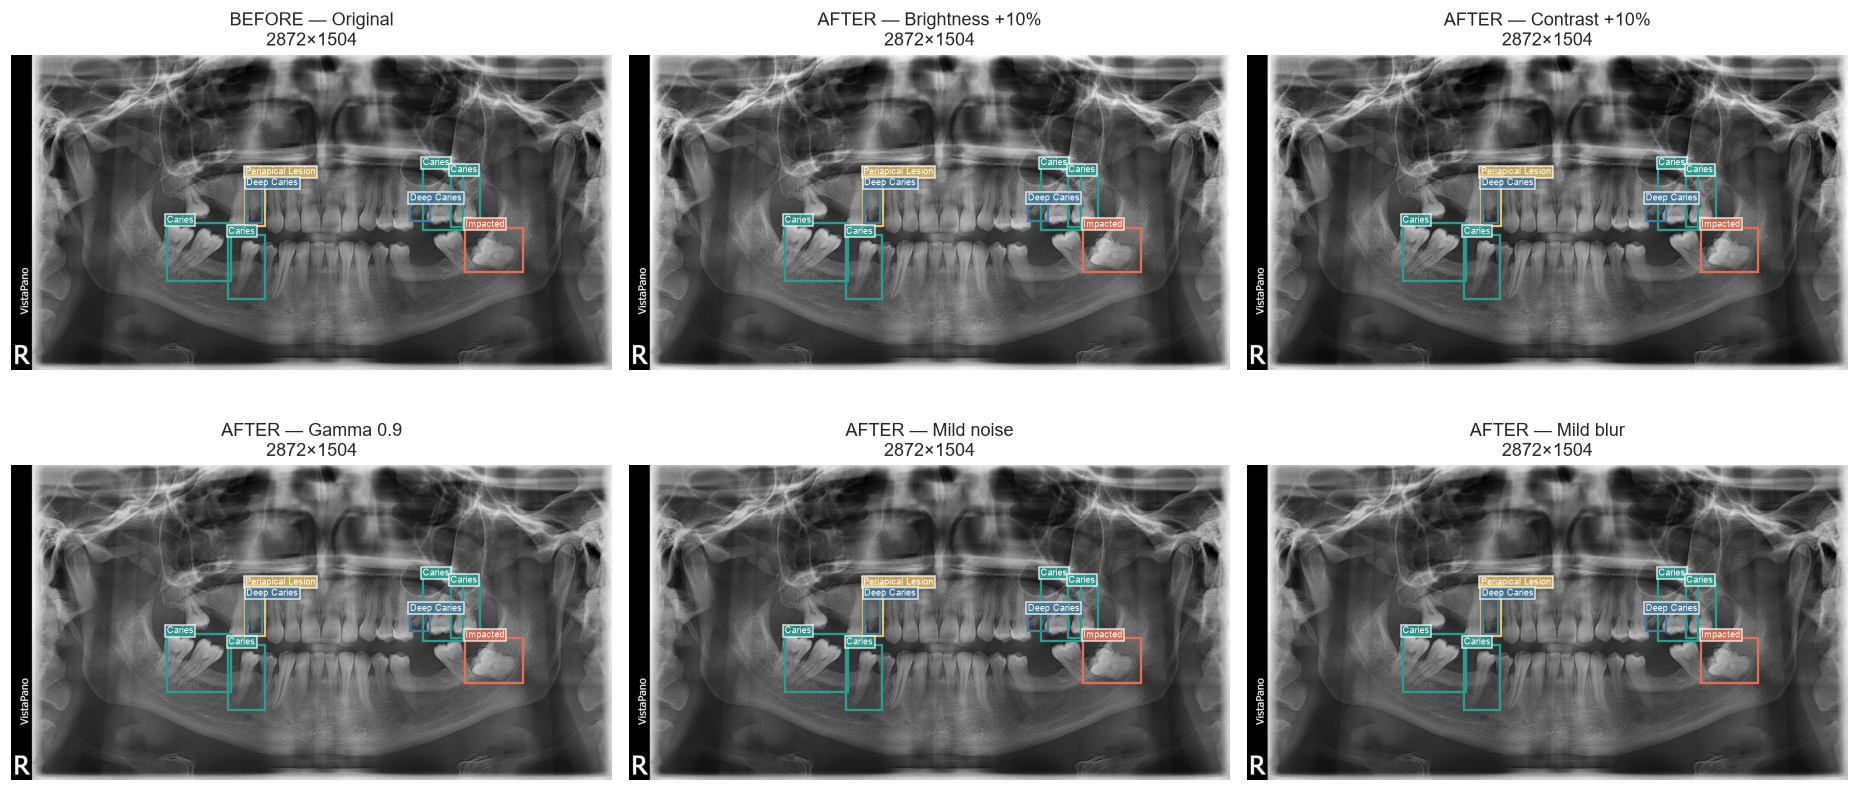

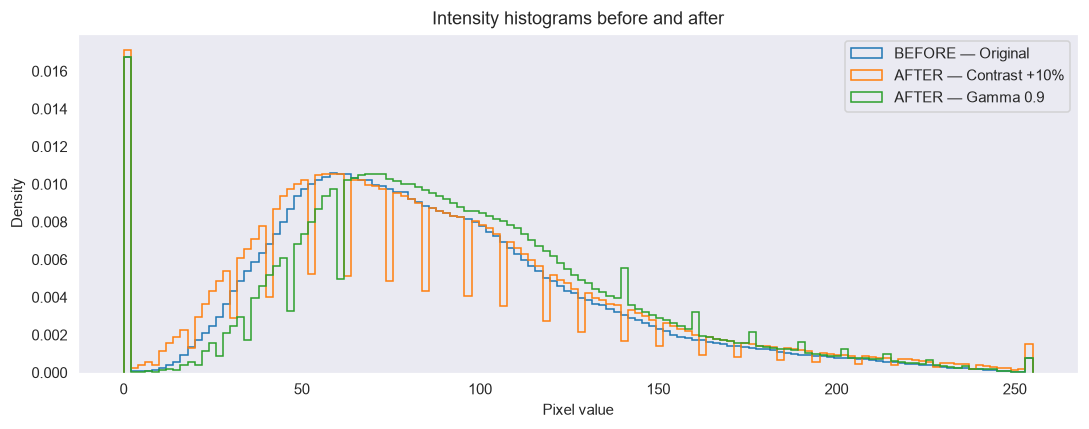

In [17]:
photometric_results=visualize_photometric_augmentations(examples["Small-object"])

In [18]:
def conservative_training_augmentation(image,boxes,seed):
    rng=np.random.default_rng(seed); angle=rng.uniform(-5,5); dx=rng.uniform(-.03,.03)*image.shape[1]; dy=rng.uniform(-.03,.03)*image.shape[0]; scale=rng.uniform(.92,1.08)
    out,b,_=affine_image_and_boxes(image,boxes,angle,dx,dy,scale,flip=False)
    out=np.array(ImageEnhance.Brightness(ImageEnhance.Contrast(Image.fromarray(out)).enhance(rng.uniform(.9,1.1))).enhance(rng.uniform(.9,1.1)))
    if rng.random()<.3: out=np.clip(out.astype(float)+rng.normal(0,3,out.shape),0,255).astype(np.uint8)
    return out,b,{"angle":angle,"dx":dx,"dy":dy,"scale":scale}

def show_combined_augmentations(row,seeds=(42,43,44,45)):
    image,boxes=get_image_boxes(row); fig,axes=plt.subplots(1,5,figsize=(20,5)); draw_detection(axes[0],image,boxes,"Original training image")
    results=[]
    for ax,seed in zip(axes[1:],seeds):
        out,b,meta=conservative_training_augmentation(image,boxes,seed); draw_detection(ax,out,b,f"Augmented sample — seed {seed}"); results.append((seed,out,b,meta))
    plt.tight_layout(); plt.show(); return results

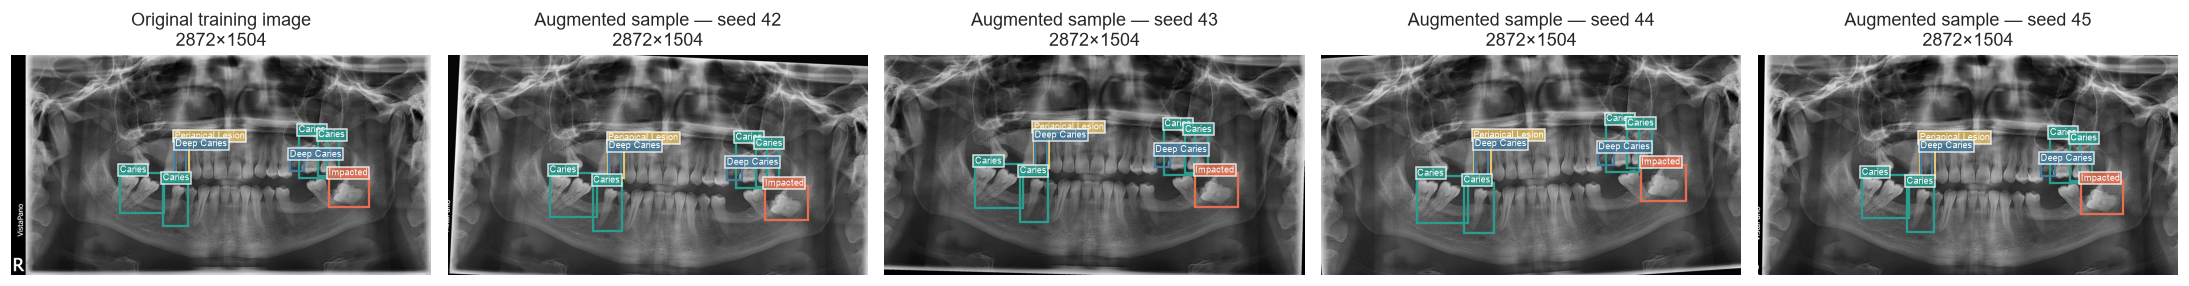

In [19]:
combined_results=show_combined_augmentations(examples["Small-object"])

**Observation.** The demonstrated photometric variants alter intensity distributions while retaining recognizable local structure and unchanged box geometry. The combined samples introduce modest reproducible variation and retain the small target and panorama context. These are validated candidate operations, not evidence that every operation belongs in the final training configuration; usefulness must be established experimentally.

## 9. Canonical COCO to YOLO Annotation Conversion

COCO remains the canonical source of truth. Ultralytics requires a derived YOLO representation in which each object is stored as

```text
class x_center y_center width height
```

For canonical COCO box $[x,y,w,h]$ in an image of width $W$ and height $H$,

$$
x_c=\frac{x+w/2}{W},\qquad
y_c=\frac{y+h/2}{H},
$$

$$
w_n=\frac{w}{W},\qquad
h_n=\frac{h}{H}.
$$

All four YOLO geometry values should lie in $[0,1]$. Each image receives a corresponding `.txt` label file; negative images receive an empty file and remain in the dataset. The derived layout contains `images/train`, `images/val`, `images/test`, matching `labels/` directories, and `data.yaml`.

Conversion is strictly one-way:

```text
Canonical COCO dataset → model-specific conversion → YOLO representation
```

It does not overwrite canonical images or COCO annotations and does not create an independent annotation authority.

In [20]:
def file_hash(path,chunk=1<<20):
    h=hashlib.sha256()
    with path.open("rb") as f:
        while data:=f.read(chunk): h.update(data)
    return h.hexdigest()

canonical_manifest_before={str(p.relative_to(DATA_ROOT)):file_hash(p) for p in sorted(DATA_ROOT.rglob("*")) if p.is_file()}
split_membership_before={s:tuple(sorted(x["file_name"] for x in payloads[s]["images"])) for s in SPLITS}

In [21]:
def convert_coco_to_yolo(payloads,source_root,output_root):
    output_root.mkdir(parents=True,exist_ok=True); summary=[]
    for split,payload in payloads.items():
        image_out=output_root/"images"/split; label_out=output_root/"labels"/split; image_out.mkdir(parents=True,exist_ok=True); label_out.mkdir(parents=True,exist_ok=True)
        expected={x["file_name"] for x in payload["images"]}
        for stale in image_out.iterdir():
            if stale.is_file() and stale.name not in expected: stale.unlink()
        lookup={int(x["id"]):x for x in payload["images"]}; grouped=defaultdict(list)
        for a in payload["annotations"]: grouped[int(a["image_id"])].append(a)
        for im in payload["images"]:
            src=source_root/"images"/split/im["file_name"]; dst=image_out/im["file_name"]
            if not dst.exists() or file_hash(dst)!=file_hash(src): shutil.copy2(src,dst)
            lines=[]
            for a in grouped[int(im["id"])]:
                x,y,w,h=map(float,a["bbox"]); xc=(x+w/2)/im["width"]; yc=(y+h/2)/im["height"]; wn=w/im["width"]; hn=h/im["height"]
                lines.append(f"{int(a['category_id'])} {xc:.10f} {yc:.10f} {wn:.10f} {hn:.10f}")
            (label_out/Path(im["file_name"]).with_suffix(".txt")).write_text("\n".join(lines)+("\n" if lines else ""),encoding="utf-8")
        summary.append({"split":split,"images":len(payload["images"]),"labels":len(list(label_out.glob("*.txt"))),"objects":sum(len(v) for v in grouped.values())})
    yaml="path: "+output_root.as_posix()+"\ntrain: images/train\nval: images/val\ntest: images/test\nnames:\n"+"".join(f"  {i}: {name}\n" for i,name in CLASS_NAMES.items())
    (output_root/"data.yaml").write_text(yaml,encoding="utf-8")
    return pd.DataFrame(summary)

In [22]:
conversion_summary=convert_coco_to_yolo(payloads,DATA_ROOT,MODEL_ROOT)
display(conversion_summary)

,split,images,labels,objects
0,train,493,493,2442
1,val,106,106,548
2,test,106,106,539


**Observation.** The generated YOLO representation contains 493/106/106 images and label files for train/validation/test, with 2,442/548/539 objects respectively. Empty labels preserve negative images. The split membership and class IDs remain inherited from canonical COCO.

## 10. YOLO Reconstruction and Conversion Validation

Conversion is checked in both directions. Normalized YOLO coordinates are reconstructed in image pixels and overlaid beside canonical COCO boxes. The automated audit also verifies five values per non-empty row, valid class IDs, normalized geometry in `[0,1]`, and exact object-count preservation. Small sub-pixel differences are expected only from decimal serialization.

In [24]:
def read_yolo_boxes(label_path,width,height):
    boxes=[]
    for line in label_path.read_text(encoding="utf-8").splitlines():
        c,xc,yc,w,h=map(float,line.split()); bw=w*width; bh=h*height; boxes.append([(xc-w/2)*width,(yc-h/2)*height,bw,bh,int(c),-1])
    return np.asarray(boxes,float)

def compare_coco_and_yolo_annotations(rows):
    error_rows=[]; fig,axes=plt.subplots(len(rows),2,figsize=(15,4*len(rows)))
    for r,(ax1,ax2) in zip(rows.itertuples(),np.atleast_2d(axes)):
        image,coco_boxes=get_image_boxes(pd.Series(r._asdict())); yolo=read_yolo_boxes(MODEL_ROOT/"labels"/r.split/Path(r.file_name).with_suffix(".txt"),r.width,r.height)
        draw_detection(ax1,image,coco_boxes,"COCO annotation"); draw_detection(ax2,image,yolo,"YOLO reconstructed annotation")
        ordered_coco=coco_boxes[np.lexsort((coco_boxes[:,0],coco_boxes[:,4]))]; ordered_yolo=yolo[np.lexsort((yolo[:,0],yolo[:,4]))]
        error_rows.append({"file_name":r.file_name,"boxes":len(yolo),"maximum_coordinate_error_px":float(np.max(np.abs(ordered_coco[:,:4]-ordered_yolo[:,:4]))) if len(yolo) else 0})
    plt.tight_layout(); plt.show(); return pd.DataFrame(error_rows)

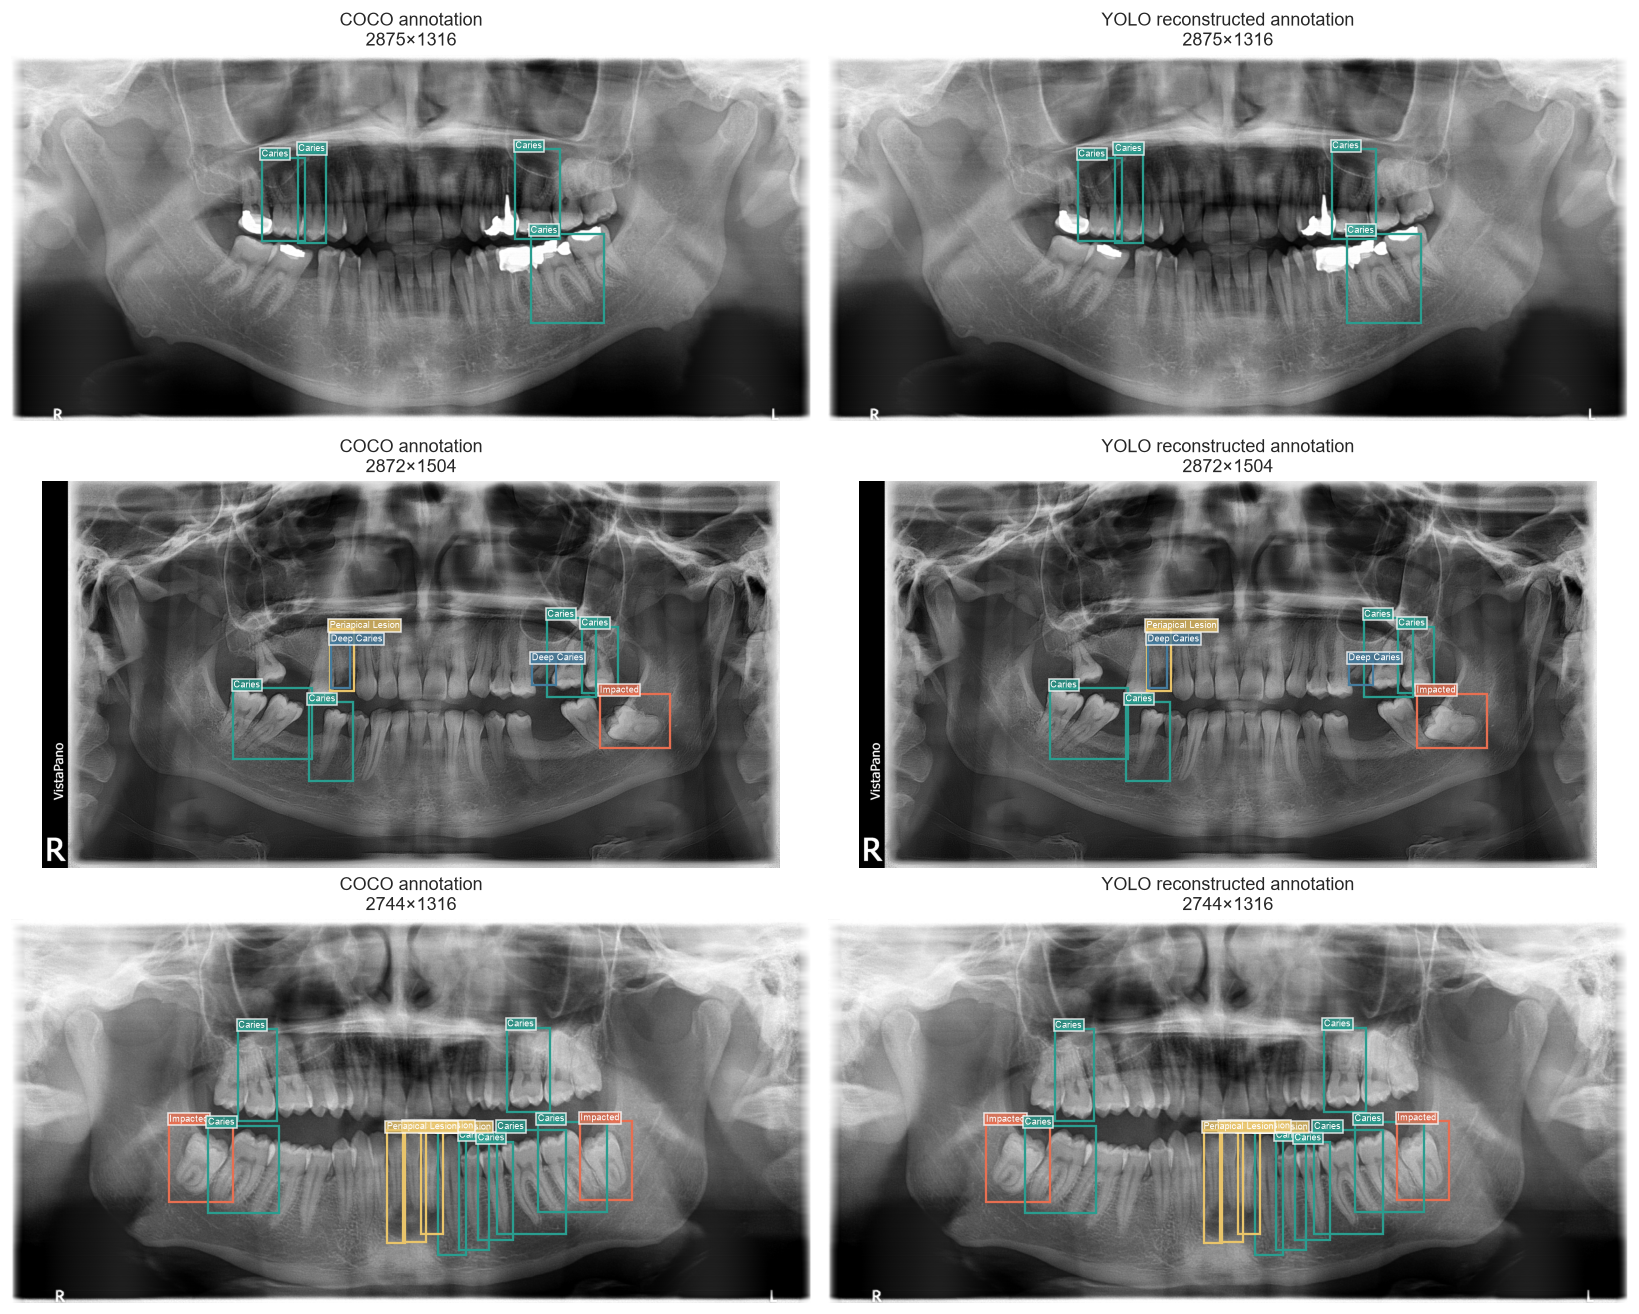

,file_name,boxes,maximum_coordinate_error_px
0,train_120.png,4,1.250619e-07
1,train_141.png,8,1.653189e-07
2,train_673.png,13,1.336000e-07


In [25]:
comparison_rows=pd.DataFrame([examples["Typical"],examples["Small-object"],examples["Rarest class"]]).drop_duplicates("image_id")
reconstruction_report=compare_coco_and_yolo_annotations(comparison_rows)
display(reconstruction_report)

In [26]:
def validate_yolo_conversion(payloads,model_root):
    rows=[]
    for split,payload in payloads.items():
        object_count=0; invalid=0
        for im in payload["images"]:
            label=model_root/"labels"/split/Path(im["file_name"]).with_suffix(".txt")
            for line in label.read_text(encoding="utf-8").splitlines():
                values=list(map(float,line.split())); object_count+=1
                if len(values)!=5 or int(values[0]) not in CLASS_NAMES or not all(0<=v<=1 for v in values[1:]): invalid+=1
        rows.append({"split":split,"expected_objects":len(payload["annotations"]),"yolo_objects":object_count,"invalid_rows":invalid})
    report=pd.DataFrame(rows)
    if not ((report.expected_objects==report.yolo_objects)&(report.invalid_rows==0)).all(): raise RuntimeError("YOLO validation failed")
    return report

In [28]:
yolo_validation=validate_yolo_conversion(payloads,MODEL_ROOT)
display(yolo_validation)

,split,expected_objects,yolo_objects,invalid_rows
0,train,2442,2442,0
1,val,548,548,0
2,test,539,539,0


**Observation.** Reconstructed YOLO boxes visually coincide with their COCO counterparts. Maximum coordinate differences in the representative examples remain around $10^{-7}$ pixels. All 3,529 annotations are transferred, no invalid YOLO rows are found, and every negative image retains an empty label file.

## 11. Final Pipeline and Integrity Verification

The validated operational sequence is:

```text
Canonical COCO dataset
        ↓
model-specific conversion or image loading
        ↓
aspect-ratio-preserving letterbox
        ↓
training only: conservative geometric + photometric augmentation
        ↓
framework-specific normalization
        ↓
model input
```

For validation and test, stochastic augmentation is omitted:

```text
Canonical image → deterministic letterbox → framework normalization → model input
```

The final check hashes every canonical processed file before and after model-specific generation and compares split membership. This verifies that preprocessing artifacts are derived without changing the canonical COCO dataset.

In [29]:
canonical_manifest_after={str(p.relative_to(DATA_ROOT)):file_hash(p) for p in sorted(DATA_ROOT.rglob("*")) if p.is_file()}
split_membership_after={s:tuple(sorted(x["file_name"] for x in payloads[s]["images"])) for s in SPLITS}
assert canonical_manifest_after==canonical_manifest_before
assert split_membership_after==split_membership_before
assert yolo_validation.invalid_rows.sum()==0 and yolo_validation.yolo_objects.sum()==3529
assert conversion_summary.images.sum()==705
integrity_report=pd.DataFrame({"Status":[canonical_manifest_after==canonical_manifest_before,split_membership_after==split_membership_before,int(yolo_validation.yolo_objects.sum())==3529,int(conversion_summary.images.sum())==705]},index=["Canonical files unchanged","Split membership unchanged","All annotations converted","All images represented"])
display(integrity_report)

,Status
Canonical files unchanged,True
Split membership unchanged,True
All annotations converted,True
All images represented,True


## 12. Preprocessing Conclusions

- The COCO-compatible dataset remains the canonical representation; model-specific data is derived from it.
- Canonical PNGs are actually encoded as RGB `uint8`, despite containing grayscale radiographic imagery. Conversion to luminance and normalization are runtime operations, not permanent rewrites.
- Aspect-ratio-preserving letterbox is preferred to direct square stretching because it preserves panoramic and object proportions.
- The 640 and 1024 comparisons illustrate the resolution trade-off only. Final input size is selected later through controlled model experiments.
- Normalization must follow the selected framework contract, and training and inference must apply the same effective preprocessing.
- Augmentation is conservative, stochastic, and training-only. Horizontal flipping is disabled by default; validation and test are deterministic.
- Geometric transformations must update boxes and labels jointly, validate boundaries and positive dimensions, and never corrupt or remove annotations silently.
- YOLO labels, image links, empty negative-image labels, and `data.yaml` are derived from canonical COCO without changing split membership or canonical files.
- Visual overlays and automated reconstruction checks confirm correct coordinate transformations and negligible serialization error.

The resulting YOLO representation is ready for the baseline training pipeline, while other detection frameworks can continue to derive their own runtime representations from the same unchanged canonical COCO source.